# Indian Used Car Market — Full Analysis

**Goal:** Explore the used-car dataset, visualize market patterns, and build regression models (including **XGBoost**) to predict **estimated final sale price**.

**Artifacts:** Models and metrics are saved under `outputs/` for the Streamlit app (`app.py`).

In [2]:
# Core imports
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (10, 5)

ROOT = Path(".").resolve()
DATA_PATH = ROOT / "final_indian_used_car_market_dataset.csv"
CONFIG_PATH = ROOT / "project_config.json"
OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

with open(CONFIG_PATH, encoding="utf-8") as f:
    config = json.load(f)

print(config["project_name"])

Indian Used Car Market — Pricing & Demand Intelligence


In [3]:
df = pd.read_csv(DATA_PATH)
TARGET = config["target_column"]
print(f"Shape: {df.shape}")
df.head()

Shape: (200, 23)


,brand,model,year,fuel_type,transmission,km_driven,owner_type,city,mileage,engine_cc,...,estimated_final_price,days_to_sell,bargain_percent,car_age,depreciation_amount,resale_value_percent,demand_score,brand_popularity_score,price_per_km,premium_car
0,Honda,Amaze,2025,Petrol,Manual,11067,Third,Delhi,15,1199,...,739003,20,8,1,236645,75.74,18.45,8,66.78,0
1,Tata,Altroz,2025,Diesel,Automatic,9114,First,Delhi,15,1199,...,579222,21,4,1,130722,81.59,16.54,7,63.55,0
2,Tata,Punch,2021,CNG,Automatic,75049,Second,Delhi,20,1199,...,466743,36,6,5,590414,44.15,3.25,7,6.22,0
3,Maruti,Brezza,2021,Petrol,Manual,74402,Second,Mumbai,19,1462,...,506724,34,5,5,598788,45.84,5.28,9,6.81,0
4,Mahindra,Scorpio,2022,Diesel,Automatic,38984,Second,Delhi,12,2184,...,701332,36,12,4,708120,49.76,8.05,8,17.99,0


## 1. Data quality & overview

In [4]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   brand                   200 non-null    object 
 1   model                   200 non-null    object 
 2   year                    200 non-null    int64  
 3   fuel_type               200 non-null    object 
 4   transmission            200 non-null    object 
 5   km_driven               200 non-null    int64  
 6   owner_type              200 non-null    object 
 7   city                    200 non-null    object 
 8   mileage                 200 non-null    int64  
 9   engine_cc               200 non-null    int64  
 10  condition_rating        200 non-null    int64  
 11  original_price          200 non-null    int64  
 12  listed_price            200 non-null    int64  
 13  estimated_final_price   200 non-null    int64  
 14  days_to_sell            200 non-null    in

,count,mean,std,min,25%,50%,75%,max
year,200.0,2.020785e+03,3.622761,2010.00,2019.0000,2022.00,2.024000e+03,2025.00
km_driven,200.0,6.346143e+04,47226.542849,8131.00,29013.0000,50760.00,8.422600e+04,232796.00
mileage,200.0,1.851500e+01,4.134640,12.00,15.0000,19.00,2.200000e+01,25.00
engine_cc,200.0,1.417000e+03,433.747408,999.00,1197.0000,1199.00,1.497000e+03,2755.00
condition_rating,200.0,6.975000e+00,1.485060,5.00,5.0000,7.00,8.000000e+00,10.00
original_price,200.0,1.371487e+06,722513.064793,510340.00,898525.0000,1092096.00,1.580006e+06,4627798.00
listed_price,200.0,6.940533e+05,457855.056230,76551.00,399940.5000,589684.00,8.689598e+05,2370945.00
estimated_final_price,200.0,6.409128e+05,429600.566072,68895.00,363705.5000,554459.00,8.086520e+05,2181269.00
days_to_sell,200.0,3.407000e+01,8.269645,18.00,28.0000,32.50,3.925000e+01,56.00
bargain_percent,200.0,8.410000e+00,2.885051,3.00,6.0000,8.00,1.000000e+01,16.00


Duplicates: 0


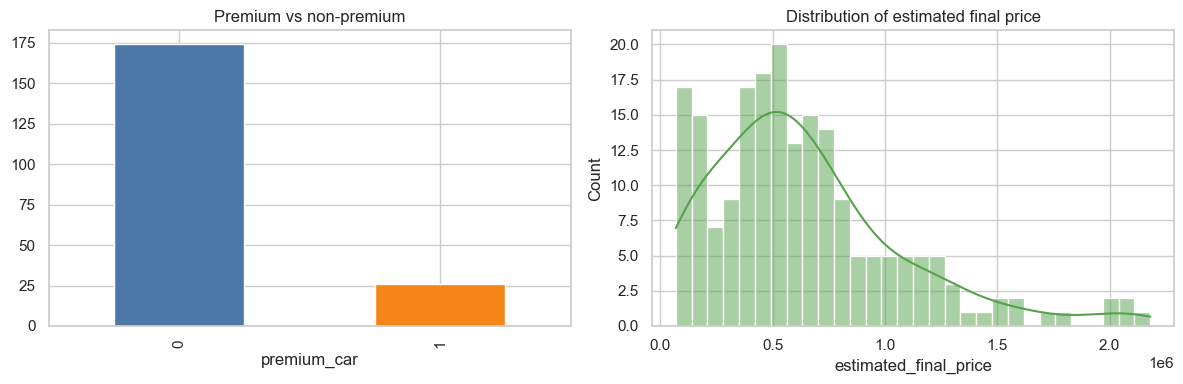

In [5]:
# Duplicate check
print("Duplicates:", df.duplicated().sum())

# Premium vs standard mix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["premium_car"].value_counts().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Premium vs non-premium")
axes[0].set_xlabel("premium_car")
sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[1], color="#54A24B")
axes[1].set_title("Distribution of estimated final price")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_price_distribution.png", dpi=120)
plt.show()

## 2. Exploratory charts

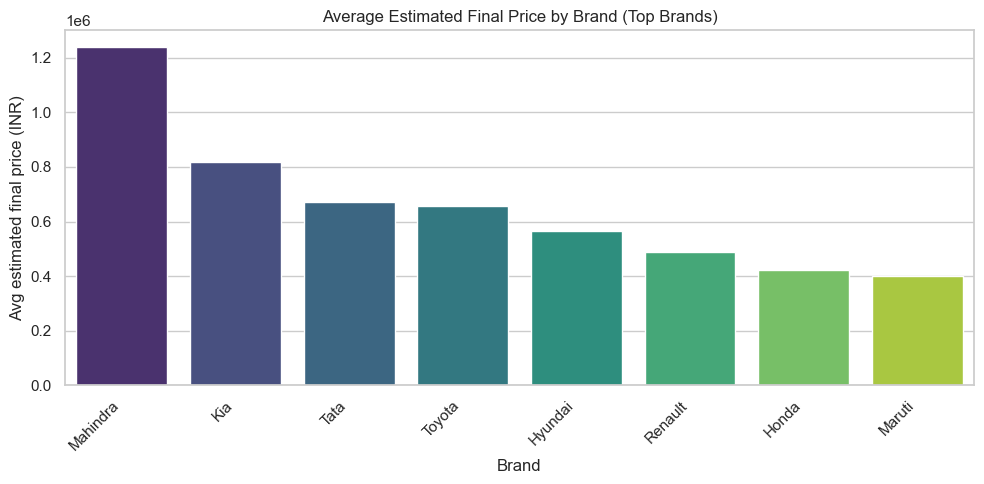

In [8]:
# Average price by brand (top 10 by volume)
import matplotlib.pyplot as plt
import seaborn as sns

# Compute average price per brand (top brands already defined by you)
brand_avg = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")[TARGET]
    .mean()
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    x=brand_avg.index,
    y=brand_avg.values,
    palette="viridis"   # gives nice visual ranking
)

# Labels & formatting
plt.xticks(rotation=45, ha="right")
plt.ylabel("Avg estimated final price (INR)")
plt.xlabel("Brand")
plt.title("Average Estimated Final Price by Brand (Top Brands)")

plt.tight_layout()
plt.show()

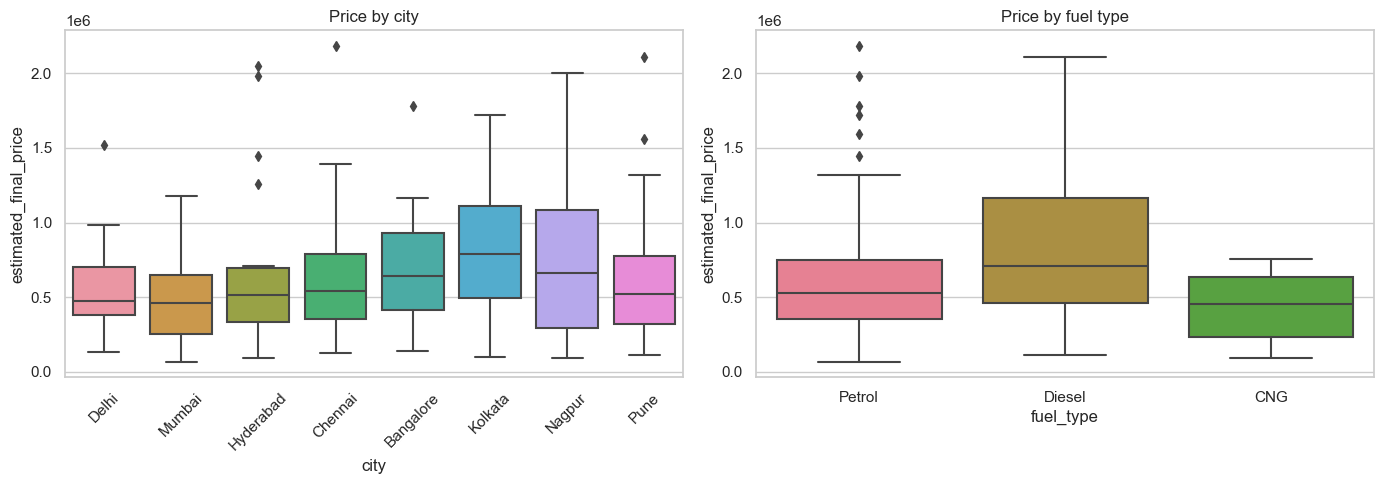

In [9]:
# City and fuel type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="city", y=TARGET, ax=axes[0])
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_title("Price by city")
sns.boxplot(data=df, x="fuel_type", y=TARGET, ax=axes[1])
axes[1].set_title("Price by fuel type")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_city_fuel_boxplots.png", dpi=120)
plt.show()

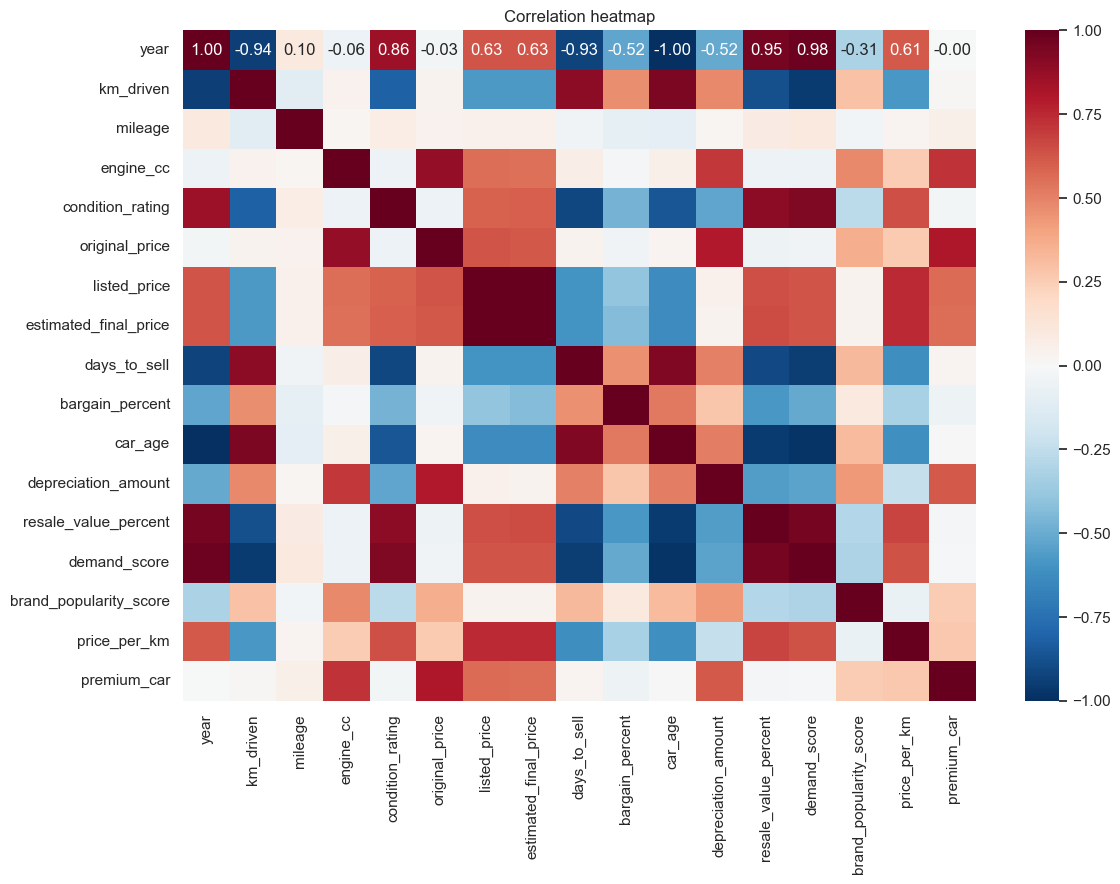

In [10]:
# Correlation among numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_correlation_heatmap.png", dpi=120)
plt.show()

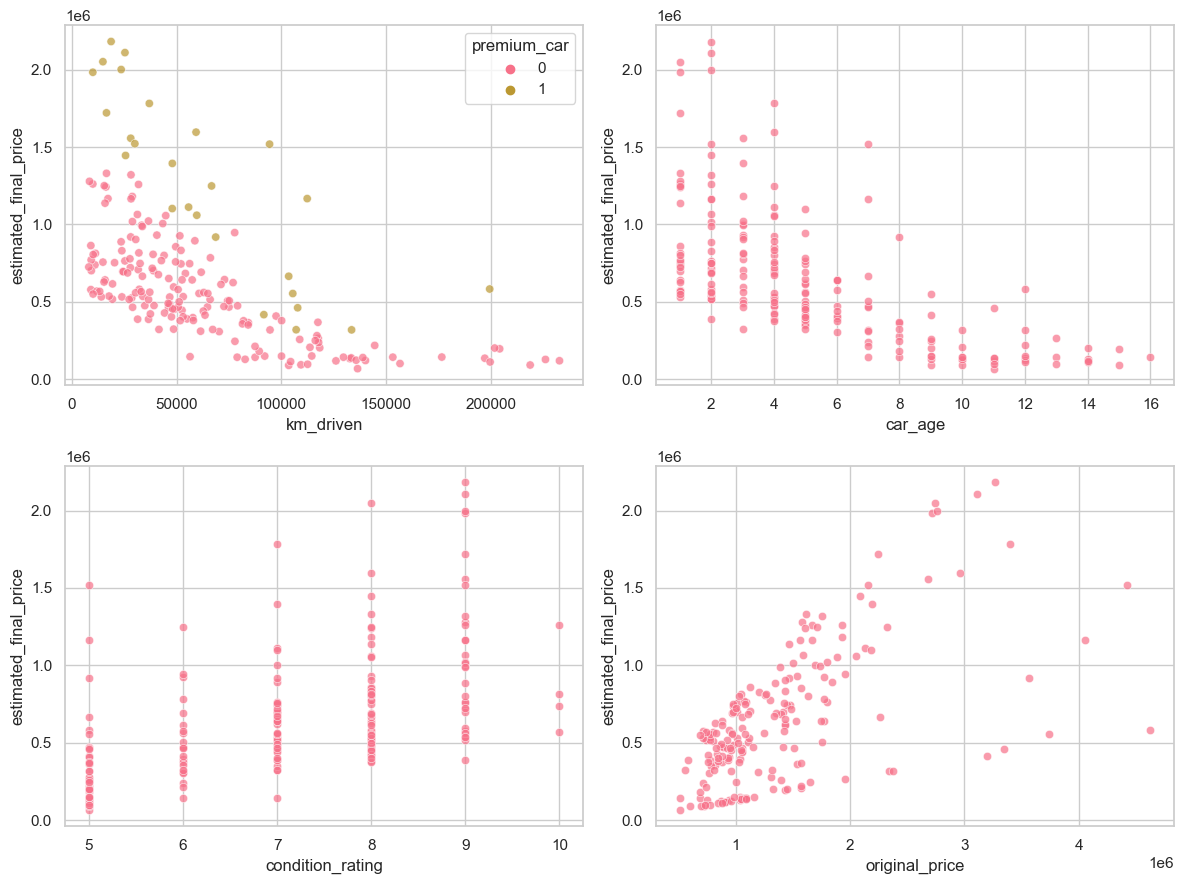

In [11]:
# Scatter relationships
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.scatterplot(data=df, x="km_driven", y=TARGET, hue="premium_car", ax=axes[0, 0], alpha=0.7)
sns.scatterplot(data=df, x="car_age", y=TARGET, ax=axes[0, 1], alpha=0.7)
sns.scatterplot(data=df, x="condition_rating", y=TARGET, ax=axes[1, 0], alpha=0.7)
sns.scatterplot(data=df, x="original_price", y=TARGET, ax=axes[1, 1], alpha=0.7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_scatter_relationships.png", dpi=120)
plt.show()

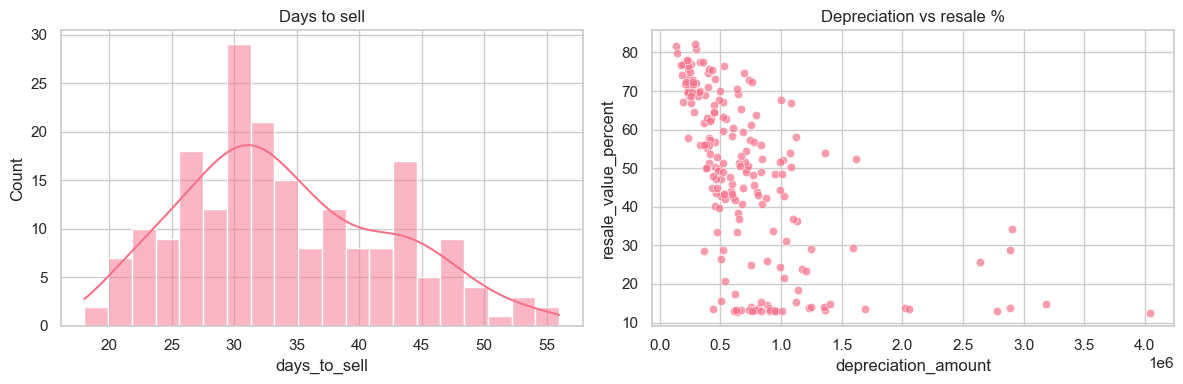

In [12]:
# Days to sell & depreciation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["days_to_sell"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Days to sell")
sns.scatterplot(data=df, x="depreciation_amount", y="resale_value_percent", ax=axes[1], alpha=0.7)
axes[1].set_title("Depreciation vs resale %")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_time_depreciation.png", dpi=120)
plt.show()

## 3. Machine learning — predict final price

In [13]:
LEAKAGE_COLS = {
    "listed_price", "estimated_final_price", "depreciation_amount",
    "resale_value_percent", "bargain_percent", "days_to_sell",
}
CATEGORICAL = ["brand", "model", "fuel_type", "transmission", "owner_type", "city"]
NUMERIC = [
    "year", "km_driven", "mileage", "engine_cc", "condition_rating",
    "original_price", "car_age", "demand_score", "brand_popularity_score",
    "price_per_km", "premium_car",
]

feature_cols = [c for c in df.columns if c not in LEAKAGE_COLS and c != TARGET]
X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ("num", StandardScaler(), NUMERIC),
])

def metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 160 | Test: 40


In [14]:
models = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.08,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
    ),
}

results = []
fitted = {}
for name, est in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    m = metrics(y_test, pred)
    m["Model"] = name
    results.append(m)
    fitted[name] = pipe
    cv = cross_val_score(pipe, X, y, cv=5, scoring="neg_root_mean_squared_error")
    print(f"{name}: RMSE={m['RMSE']:,.0f} | R2={m['R2']:.3f} | CV RMSE={-cv.mean():,.0f}")

results_df = pd.DataFrame(results).set_index("Model")
results_df

Ridge: RMSE=129,611 | R2=0.914 | CV RMSE=140,409
RandomForest: RMSE=66,032 | R2=0.978 | CV RMSE=89,507
XGBoost: RMSE=65,004 | R2=0.978 | CV RMSE=88,280


,RMSE,MAE,R2
Model,,,
Ridge,129610.838067,97269.010351,0.913891
RandomForest,66032.284393,49698.530532,0.977650
XGBoost,65004.478775,45683.438477,0.978340


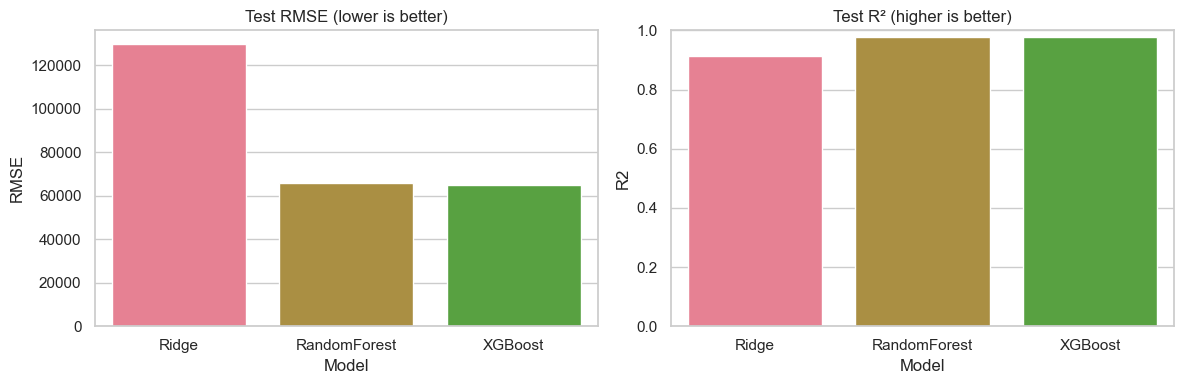

In [15]:
# Model comparison chart
plot_df = results_df.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=plot_df, x="Model", y="RMSE", ax=axes[0])
axes[0].set_title("Test RMSE (lower is better)")
sns.barplot(data=plot_df, x="Model", y="R2", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title("Test R² (higher is better)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_model_comparison.png", dpi=120)
plt.show()

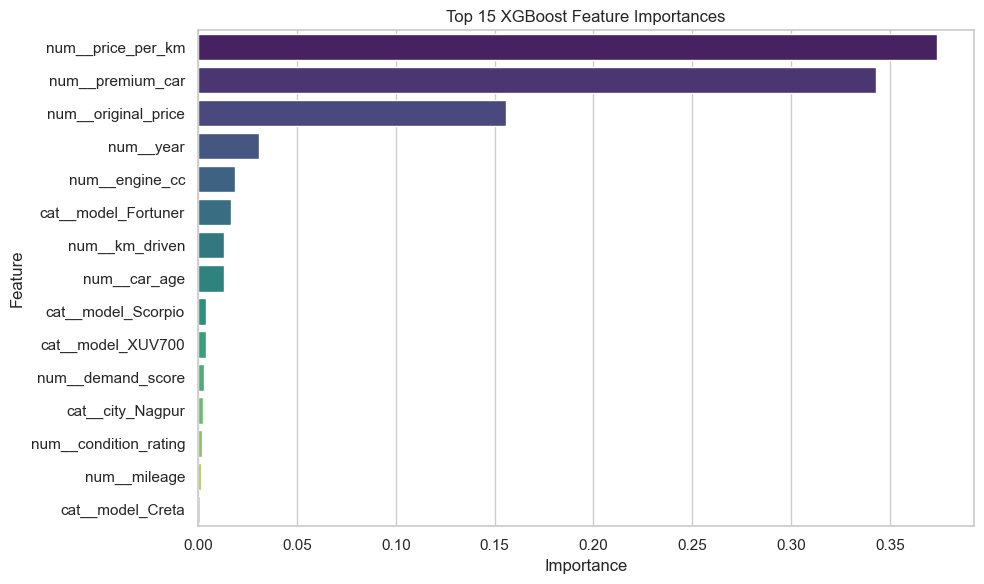

In [18]:
# XGBoost feature importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

imp_df = pd.DataFrame({
    "feature": feat_names,
    "importance": imp
}).sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=imp_df,
    y="feature",
    x="importance",
    palette="viridis"
)

plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

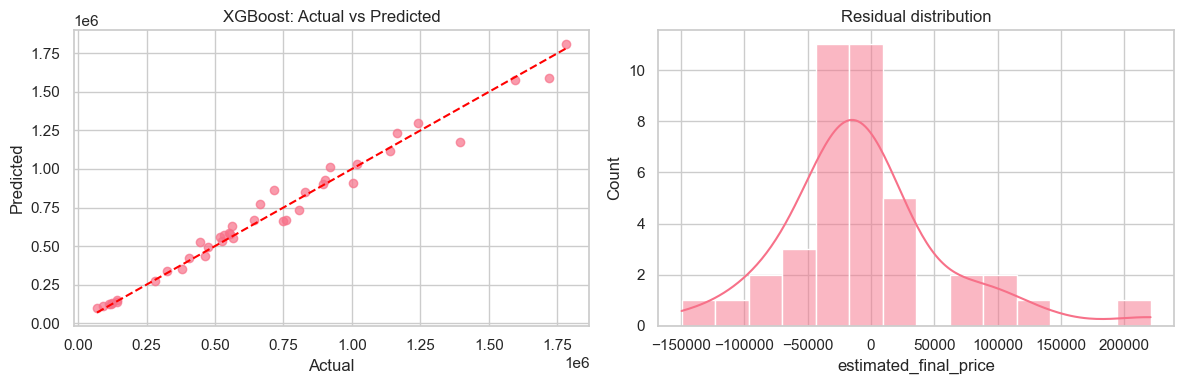

In [19]:
# Actual vs predicted (XGBoost)
pred_xgb = xgb_pipe.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_test, pred_xgb, alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted")
axes[0].set_title("XGBoost: Actual vs Predicted")
residuals = y_test - pred_xgb
sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Residual distribution")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_xgb_diagnostics.png", dpi=120)
plt.show()

In [20]:
# Save best model & metrics JSON
best_model_name = results_df["RMSE"].idxmin()
best_pipe = fitted[best_model_name]

joblib.dump(best_pipe, OUTPUT_DIR / "price_model.joblib")

metrics_out = {
    "test_metrics": results_df.reset_index().to_dict(orient="records"),
    "best_model": best_model_name,
}
with open(OUTPUT_DIR / "model_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_out, f, indent=2)

print(f"Best model: {best_model_name}")
print("Saved outputs/price_model.joblib and outputs/model_metrics.json")

Best model: XGBoost
Saved outputs/price_model.joblib and outputs/model_metrics.json


## 4. Key takeaways

- **Target:** `estimated_final_price` — fair resale value after negotiation.
- **XGBoost** typically captures non-linear effects (brand, city, mileage, condition) better than linear baselines on tabular data.
- **Watch leakage:** do not use `listed_price`, `bargain_percent`, or post-sale fields when training.
- **Next step:** run `streamlit run app.py` for an interactive dashboard and live price estimates.